Name = Arav Mahind

Roll = 24102A2008

Branch-Div = CMPN-A

Subject = R Programming

High-Performance Big Data Analytics Using R

In [1]:
# Check the R environment
R.version.string
R.home()

[1] "R version 4.6.1 (2026-06-24)"

[1] "/usr/lib/R"

In [2]:
install.packages(c(
  "arrow",
  "data.table",
  "ggplot2",
  "lubridate",
  "foreach",
  "doParallel",
  "microbenchmark",
  "purrr"
))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘assertthat’, ‘iterators’




In [4]:
library(arrow)
library(data.table)

# Official January 2024 NYC Yellow Taxi dataset
taxi_url <- "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"

# Read the dataset
taxi <- read_parquet(taxi_url)

# Convert to data.table
setDT(taxi)

# Inspect the data
dim(taxi)
head(taxi)
str(taxi)

[1] 2964624      19

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
<int>,<dttm>,<dttm>,<int>,<dbl>,<int>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,N,186,79,2,17.7,1.0,0.5,0.00,0,1,22.70,2.5,0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.80,1,N,140,236,1,10.0,3.5,0.5,3.75,0,1,18.75,2.5,0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.70,1,N,236,79,1,23.3,3.5,0.5,3.00,0,1,31.30,2.5,0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.40,1,N,79,211,1,10.0,3.5,0.5,2.00,0,1,17.00,2.5,0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.80,1,N,211,148,1,7.9,3.5,0.5,3.20,0,1,16.10,2.5,0
1,2024-01-01 00:54:08,2024-01-01 01:26:31,1,4.70,1,N,148,141,1,29.6,3.5,0.5,6.90,0,1,41.50,2.5,0


Classes ‘data.table’ and 'data.frame':	2964624 obs. of  19 variables:
 $ VendorID             : int  2 1 1 1 1 1 2 1 2 2 ...
 $ tpep_pickup_datetime : POSIXct, format: "2024-01-01 00:57:55" "2024-01-01 00:03:00" ...
 $ tpep_dropoff_datetime: POSIXct, format: "2024-01-01 01:17:43" "2024-01-01 00:09:36" ...
 $ passenger_count      : int  1 1 1 1 1 1 2 0 1 1 ...
 $ trip_distance        : num  1.72 1.8 4.7 1.4 0.8 ...
 $ RatecodeID           : int  1 1 1 1 1 1 1 1 1 1 ...
 $ store_and_fwd_flag   : chr  "N" "N" "N" "N" ...
 $ PULocationID         : int  186 140 236 79 211 148 138 246 161 113 ...
 $ DOLocationID         : int  79 236 79 211 148 141 181 231 261 113 ...
 $ payment_type         : int  2 1 1 1 1 1 1 2 2 2 ...
 $ fare_amount          : num  17.7 10 23.3 10 7.9 29.6 45.7 25.4 31 3 ...
 $ extra                : num  1 3.5 3.5 3.5 3.5 3.5 6 3.5 1 1 ...
 $ mta_tax              : num  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 ...
 $ tip_amount           : num  0 3.75 3 2 3.2 6.9 10 0 0 

In [5]:
# Count missing values in each column
missing_values <- taxi[, lapply(.SD, function(x) sum(is.na(x)))]

print(missing_values)

   VendorID tpep_pickup_datetime tpep_dropoff_datetime passenger_count
      <int>                <int>                 <int>           <int>
1:        0                    0                     0          140162
   trip_distance RatecodeID store_and_fwd_flag PULocationID DOLocationID
           <int>      <int>              <int>        <int>        <int>
1:             0     140162             140162            0            0
   payment_type fare_amount extra mta_tax tip_amount tolls_amount
          <int>       <int> <int>   <int>      <int>        <int>
1:            0           0     0       0          0            0
   improvement_surcharge total_amount congestion_surcharge Airport_fee
                   <int>        <int>                <int>       <int>
1:                     0            0               140162      140162


In [6]:
# Count completely duplicated rows
duplicate_count <- sum(duplicated(taxi))

cat("Duplicate rows:", duplicate_count, "\n")

Duplicate rows: 0 


In [7]:
# Inspect potentially invalid records
cat("Invalid trip distances:",
    sum(taxi$trip_distance <= 0, na.rm = TRUE), "\n")

cat("Negative fare amounts:",
    sum(taxi$fare_amount < 0, na.rm = TRUE), "\n")

cat("Negative total amounts:",
    sum(taxi$total_amount < 0, na.rm = TRUE), "\n")

cat("Drop-off before pickup:",
    sum(taxi$tpep_dropoff_datetime <
        taxi$tpep_pickup_datetime, na.rm = TRUE), "\n")

cat("Missing pickup timestamps:",
    sum(is.na(taxi$tpep_pickup_datetime)), "\n")

Invalid trip distances: 60371 
Negative fare amounts: 37448 
Negative total amounts: 35504 
Drop-off before pickup: 56 
Missing pickup timestamps: 0 


In [8]:
# Keep records with valid timestamps and positive trip distance
taxi_clean <- taxi[
  !is.na(tpep_pickup_datetime) &
  !is.na(tpep_dropoff_datetime) &
  tpep_dropoff_datetime >= tpep_pickup_datetime &
  trip_distance > 0
]

# Check the cleaned dataset
cat("Original rows:", nrow(taxi), "\n")
cat("Cleaned rows:", nrow(taxi_clean), "\n")
cat("Rows removed:", nrow(taxi) - nrow(taxi_clean), "\n")

# Verify the cleaning
cat("Invalid distances remaining:",
    sum(taxi_clean$trip_distance <= 0, na.rm = TRUE), "\n")

cat("Invalid timestamps remaining:",
    sum(taxi_clean$tpep_dropoff_datetime <
        taxi_clean$tpep_pickup_datetime, na.rm = TRUE), "\n")

Original rows: 2964624 
Cleaned rows: 2904197 
Rows removed: 60427 
Invalid distances remaining: 0 
Invalid timestamps remaining: 0 


In [9]:
library(lubridate)

taxi_clean[, `:=`(
  pickup_hour = hour(tpep_pickup_datetime),
  pickup_day = day(tpep_pickup_datetime),
  pickup_weekday = wday(
    tpep_pickup_datetime,
    label = TRUE,
    abbr = FALSE
  ),
  pickup_month = month(
    tpep_pickup_datetime,
    label = TRUE,
    abbr = FALSE
  )
)]

# View the new columns
taxi_clean[, .(
  tpep_pickup_datetime,
  pickup_hour,
  pickup_day,
  pickup_weekday,
  pickup_month
)][1:10]


Attaching package: ‘lubridate’


The following objects are masked from ‘package:data.table’:

    hour, isoweek, isoyear, mday, minute, month, quarter, second, wday,
    week, yday, year


The following object is masked from ‘package:arrow’:

    duration


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




tpep_pickup_datetime,pickup_hour,pickup_day,pickup_weekday,pickup_month
<dttm>,<int>,<int>,<ord>,<ord>
2024-01-01 00:57:55,0,1,Monday,January
2024-01-01 00:03:00,0,1,Monday,January
2024-01-01 00:17:06,0,1,Monday,January
2024-01-01 00:36:38,0,1,Monday,January
2024-01-01 00:46:51,0,1,Monday,January
2024-01-01 00:54:08,0,1,Monday,January
2024-01-01 00:49:44,0,1,Monday,January
2024-01-01 00:30:40,0,1,Monday,January
2024-01-01 00:26:01,0,1,Monday,January


In [10]:
zone_url <- "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

zones <- fread(zone_url)

# Inspect the lookup table
head(zones)
str(zones)

LocationID,Borough,Zone,service_zone
<int>,<chr>,<chr>,<chr>
1,EWR,Newark Airport,EWR
2,Queens,Jamaica Bay,Boro Zone
3,Bronx,Allerton/Pelham Gardens,Boro Zone
4,Manhattan,Alphabet City,Yellow Zone
5,Staten Island,Arden Heights,Boro Zone
6,Staten Island,Arrochar/Fort Wadsworth,Boro Zone


Classes ‘data.table’ and 'data.frame':	265 obs. of  4 variables:
 $ LocationID  : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Borough     : chr  "EWR" "Queens" "Bronx" "Manhattan" ...
 $ Zone        : chr  "Newark Airport" "Jamaica Bay" "Allerton/Pelham Gardens" "Alphabet City" ...
 $ service_zone: chr  "EWR" "Boro Zone" "Boro Zone" "Yellow Zone" ...
 - attr(*, ".internal.selfref")=<pointer: 0x5c741b70b240> 


In [11]:
# Prepare pickup zone information
pickup_zones <- zones[, .(
  PULocationID = LocationID,
  pickup_borough = Borough,
  pickup_zone = Zone
)]

# Prepare drop-off zone information
dropoff_zones <- zones[, .(
  DOLocationID = LocationID,
  dropoff_borough = Borough,
  dropoff_zone = Zone
)]

# Join pickup and drop-off zone details
taxi_clean[
  pickup_zones,
  on = "PULocationID",
  `:=`(
    pickup_borough = i.pickup_borough,
    pickup_zone = i.pickup_zone
  )
]

taxi_clean[
  dropoff_zones,
  on = "DOLocationID",
  `:=`(
    dropoff_borough = i.dropoff_borough,
    dropoff_zone = i.dropoff_zone
  )
]

# Check the joined data
taxi_clean[, .(
  PULocationID, pickup_borough, pickup_zone,
  DOLocationID, dropoff_borough, dropoff_zone
)][1:10]

PULocationID,pickup_borough,pickup_zone,DOLocationID,dropoff_borough,dropoff_zone
<int>,<chr>,<chr>,<int>,<chr>,<chr>
186,Manhattan,Penn Station/Madison Sq West,79,Manhattan,East Village
140,Manhattan,Lenox Hill East,236,Manhattan,Upper East Side North
236,Manhattan,Upper East Side North,79,Manhattan,East Village
79,Manhattan,East Village,211,Manhattan,SoHo
211,Manhattan,SoHo,148,Manhattan,Lower East Side
148,Manhattan,Lower East Side,141,Manhattan,Lenox Hill West
138,Queens,LaGuardia Airport,181,Brooklyn,Park Slope
246,Manhattan,West Chelsea/Hudson Yards,231,Manhattan,TriBeCa/Civic Center
161,Manhattan,Midtown Center,261,Manhattan,World Trade Center


In [12]:
cat("Total cleaned trips:", nrow(taxi_clean), "\n")

cat("Missing pickup zones:",
    sum(is.na(taxi_clean$pickup_zone)), "\n")

cat("Missing drop-off zones:",
    sum(is.na(taxi_clean$dropoff_zone)), "\n")

Total cleaned trips: 2904197 
Missing pickup zones: 0 
Missing drop-off zones: 0 


In [13]:
# Count trips for each pickup hour
hourly_trips <- taxi_clean[
  ,
  .(total_trips = .N),
  by = pickup_hour
][order(pickup_hour)]

print(hourly_trips)

# Identify the busiest hour
busiest_hour <- hourly_trips[
  which.max(total_trips)
]

print(busiest_hour)

    pickup_hour total_trips
          <int>       <int>
 1:           0       76542
 2:           1       51346
 3:           2       35644
 4:           3       23441
 5:           4       15685
 6:           5       17838
 7:           6       39925
 8:           7       81592
 9:           8      114486
10:           9      126747
11:          10      136780
12:          11      148233
13:          12      161710
14:          13      167199
15:          14      179901
16:          15      186067
17:          16      187070
18:          17      202511
19:          18      208739
20:          19      180938
21:          20      157465
22:          21      157869
23:          22      140184
24:          23      106285
    pickup_hour total_trips
          <int>       <int>
   pickup_hour total_trips
         <int>       <int>
1:          18      208739


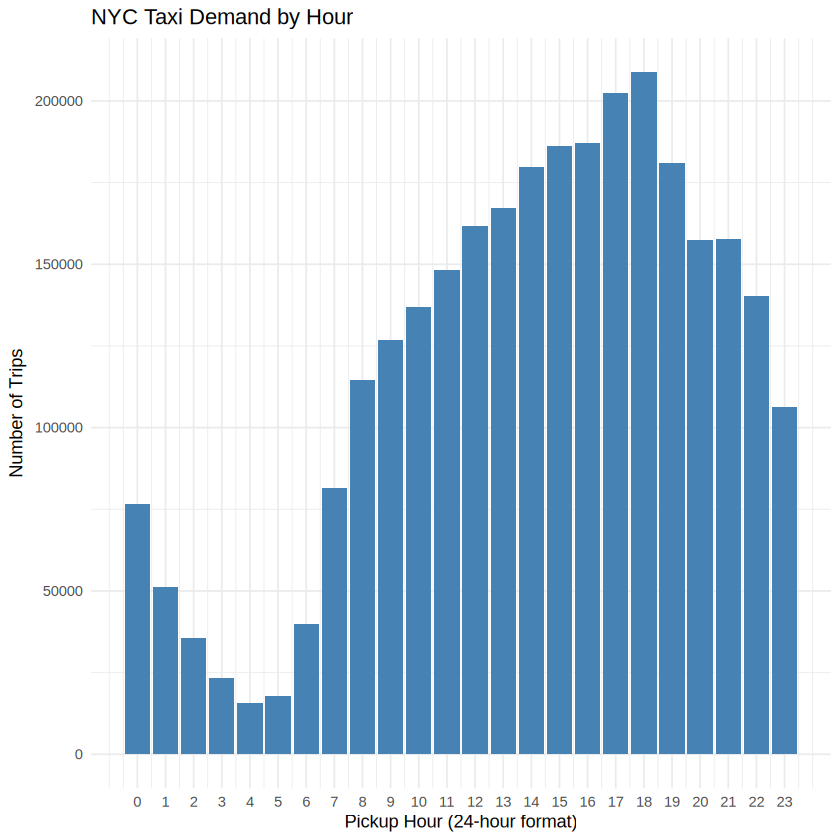

In [14]:
library(ggplot2)

ggplot(hourly_trips,
       aes(x = pickup_hour, y = total_trips)) +
  geom_col(fill = "steelblue") +
  scale_x_continuous(breaks = 0:23) +
  labs(
    title = "NYC Taxi Demand by Hour",
    x = "Pickup Hour (24-hour format)",
    y = "Number of Trips"
  ) +
  theme_minimal()

In [15]:
# Count trips by day of the week
weekday_trips <- taxi_clean[
  ,
  .(total_trips = .N),
  by = pickup_weekday
][order(-total_trips)]

print(weekday_trips)

   pickup_weekday total_trips
            <ord>       <int>
1:      Wednesday      486173
2:        Tuesday      454282
3:       Thursday      420899
4:       Saturday      412364
5:         Friday      401167
6:         Monday      398157
7:         Sunday      331155


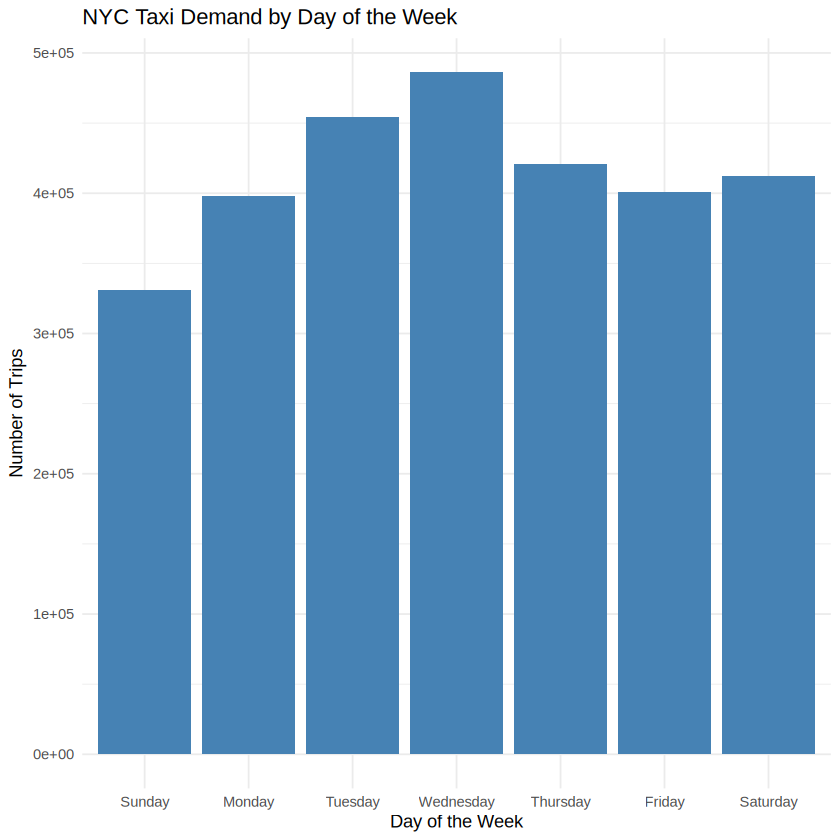

In [16]:
ggplot(weekday_trips,
       aes(x = pickup_weekday, y = total_trips)) +
  geom_col(fill = "steelblue") +
  labs(
    title = "NYC Taxi Demand by Day of the Week",
    x = "Day of the Week",
    y = "Number of Trips"
  ) +
  theme_minimal()

In [17]:
monthly_trips <- taxi_clean[
  ,
  .(total_trips = .N),
  by = pickup_month
]

print(monthly_trips)

   pickup_month total_trips
          <ord>       <int>
1:      January     2904182
2:     December          12
3:     February           3


In [18]:
# Check the actual pickup dates
taxi_clean[
  month(tpep_pickup_datetime) != 1,
  .(
    pickup_datetime = tpep_pickup_datetime,
    pickup_month = month(tpep_pickup_datetime)
  )
]

pickup_datetime,pickup_month
<dttm>,<dbl>
2023-12-31 23:56:46,12
2023-12-31 23:39:17,12
2023-12-31 23:41:02,12
2023-12-31 23:57:17,12
2023-12-31 23:56:45,12
2023-12-31 23:49:12,12
2023-12-31 23:47:28,12
2023-12-31 23:58:35,12
2023-12-31 23:58:37,12


In [19]:
january_taxi <- taxi_clean[
  tpep_pickup_datetime >= as.POSIXct("2024-01-01", tz = "UTC") &
  tpep_pickup_datetime < as.POSIXct("2024-02-01", tz = "UTC")
]

cat("January trips:", nrow(january_taxi), "\n")

January trips: 2904179 


In [20]:
fare_summary <- january_taxi[
  ,
  .(
    average_fare = mean(fare_amount, na.rm = TRUE),
    average_total_amount = mean(total_amount, na.rm = TRUE),
    total_amount_sum = sum(total_amount, na.rm = TRUE)
  )
]

print(fare_summary)

   average_fare average_total_amount total_amount_sum
          <num>                <num>            <num>
1:     18.05969              26.7489         77683607


In [21]:
top_pickup_zones <- january_taxi[
  !is.na(pickup_zone),
  .(total_trips = .N),
  by = .(pickup_borough, pickup_zone)
][order(-total_trips)][1:10]

print(top_pickup_zones)

    pickup_borough                  pickup_zone total_trips
            <char>                       <char>       <int>
 1:         Queens                  JFK Airport      142117
 2:      Manhattan               Midtown Center      141799
 3:      Manhattan        Upper East Side South      141489
 4:      Manhattan        Upper East Side North      135042
 5:      Manhattan                 Midtown East      105520
 6:      Manhattan    Times Sq/Theatre District      104559
 7:      Manhattan Penn Station/Madison Sq West      103321
 8:      Manhattan          Lincoln Square East      102848
 9:         Queens            LaGuardia Airport       88547
10:      Manhattan        Upper West Side South       87259


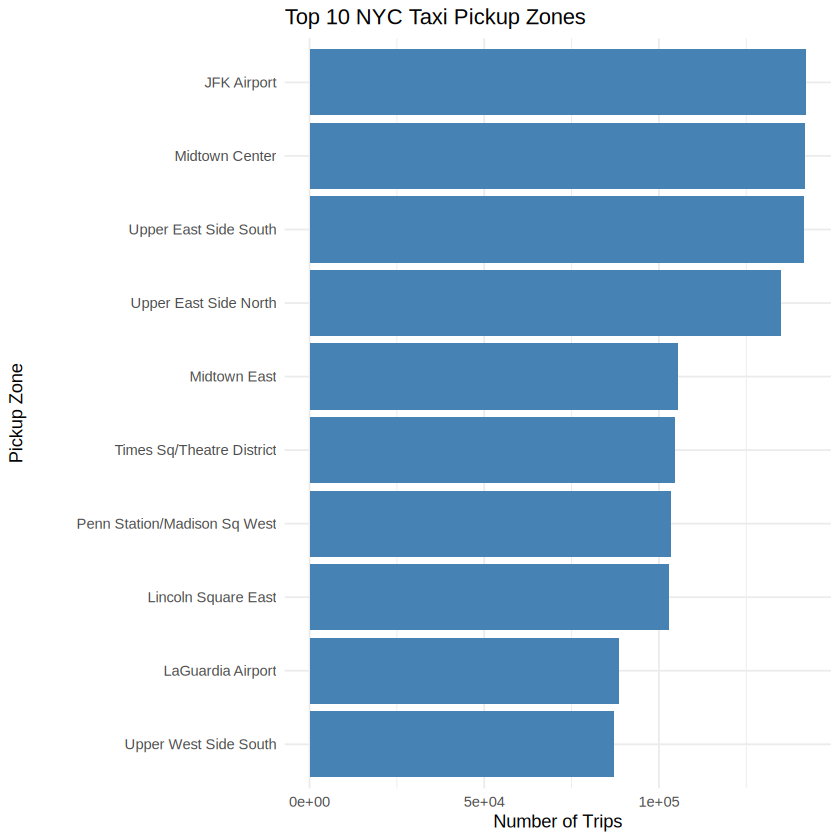

In [22]:
ggplot(
  top_pickup_zones,
  aes(
    x = reorder(pickup_zone, total_trips),
    y = total_trips
  )
) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Top 10 NYC Taxi Pickup Zones",
    x = "Pickup Zone",
    y = "Number of Trips"
  ) +
  theme_minimal()

In [23]:
library(data.table)
library(microbenchmark)

set.seed(42)

sample_taxi <- january_taxi[
  sample(.N, min(100000, .N))
]

fare_values <- sample_taxi$fare_amount

In [24]:
loop_sum <- function(x) {
  total <- 0

  for (i in seq_along(x)) {
    if (!is.na(x[i])) {
      total <- total + x[i]
    }
  }

  total
}

loop_result <- loop_sum(fare_values)
print(loop_result)

[1] 1814894


In [25]:
vector_result <- sum(fare_values, na.rm = TRUE)
print(vector_result)

[1] 1814894


In [26]:
datatable_result <- sample_taxi[
  , sum(fare_amount, na.rm = TRUE)
]

print(datatable_result)

[1] 1814894


In [27]:
benchmark_results <- microbenchmark(
  For_Loop = loop_sum(fare_values),
  Vectorization = sum(fare_values, na.rm = TRUE),
  Data_Table = sample_taxi[, sum(fare_amount, na.rm = TRUE)],
  times = 5
)

print(benchmark_results)

Unit: microseconds
          expr       min        lq     mean    median        uq       max neval
      For_Loop 24125.263 44270.838 41782.79 45812.410 46783.897 47921.550     5
 Vectorization   103.805   113.416   152.39   159.303   184.813   200.613     5
    Data_Table   660.668   733.917  1000.82  1025.754  1161.834  1421.927     5


In [28]:
library(purrr)

numeric_data <- january_taxi[
  ,
  .(fare_amount, trip_distance, total_amount)
]

numeric_data <- numeric_data[complete.cases(numeric_data)]

numeric_matrix <- as.matrix(numeric_data)


Attaching package: ‘purrr’


The following object is masked from ‘package:data.table’:

    transpose




In [29]:
apply_results <- apply(
  numeric_matrix,
  2,
  function(x) c(
    Mean = mean(x),
    Minimum = min(x),
    Maximum = max(x)
  )
)

print(apply_results)

        fare_amount trip_distance total_amount
Mean       18.05969  3.728023e+00      26.7489
Minimum  -899.00000  1.000000e-02    -900.0000
Maximum  2221.30000  3.127223e+05    2225.3000


In [30]:
lapply_results <- lapply(
  numeric_data,
  function(x) c(
    Mean = mean(x),
    Minimum = min(x),
    Maximum = max(x)
  )
)

print(lapply_results)

$fare_amount
      Mean    Minimum    Maximum 
  18.05969 -899.00000 2221.30000 

$trip_distance
        Mean      Minimum      Maximum 
3.728023e+00 1.000000e-02 3.127223e+05 

$total_amount
     Mean   Minimum   Maximum 
  26.7489 -900.0000 2225.3000 



In [31]:
map_results <- purrr::map(
  numeric_data,
  ~ c(
    Mean = mean(.x),
    Minimum = min(.x),
    Maximum = max(.x)
  )
)

print(map_results)

$fare_amount
      Mean    Minimum    Maximum 
  18.05969 -899.00000 2221.30000 

$trip_distance
        Mean      Minimum      Maximum 
3.728023e+00 1.000000e-02 3.127223e+05 

$total_amount
     Mean   Minimum   Maximum 
  26.7489 -900.0000 2225.3000 



In [32]:
library(foreach)
library(doParallel)
library(microbenchmark)

fare_chunks <- split(
  fare_values,
  cut(
    seq_along(fare_values),
    breaks = 4,
    labels = FALSE
  )
)


Attaching package: ‘foreach’


The following objects are masked from ‘package:purrr’:

    accumulate, when


Loading required package: iterators

Loading required package: parallel



In [33]:
sequential_result <- foreach(
  chunk = fare_chunks,
  .combine = "+"
) %do% {
  sum(chunk, na.rm = TRUE)
}

print(sequential_result)

[1] 1814894


In [34]:
workers <- min(4, parallel::detectCores())

cl <- parallel::makeCluster(workers)
registerDoParallel(cl)

parallel_result <- foreach(
  chunk = fare_chunks,
  .combine = "+"
) %dopar% {
  sum(chunk, na.rm = TRUE)
}

print(parallel_result)

stopImplicitCluster()
parallel::stopCluster(cl)

[1] 1814894


In [35]:
cat("Sequential result:", sequential_result, "\n")
cat("Parallel result:", parallel_result, "\n")
cat("Results match:", isTRUE(all.equal(
  sequential_result,
  parallel_result
)), "\n")

Sequential result: 1814894 
Parallel result: 1814894 
Results match: TRUE 


In [36]:
library(microbenchmark)

parallel_benchmark <- microbenchmark(
  Sequential = {
    foreach(chunk = fare_chunks, .combine = "+") %do% {
      sum(chunk, na.rm = TRUE)
    }
  },
  Parallel = {
    cl <- parallel::makeCluster(2)
    doParallel::registerDoParallel(cl)

    result <- foreach(chunk = fare_chunks, .combine = "+") %dopar% {
      sum(chunk, na.rm = TRUE)
    }

    parallel::stopCluster(cl)
    result
  },
  times = 3
)

print(parallel_benchmark)

Unit: milliseconds
       expr        min         lq       mean     median         uq        max
 Sequential   2.914971   3.180376   3.412981   3.445781   3.661987   3.878192
   Parallel 414.135977 420.414905 428.439548 426.693832 435.591334 444.488836
 neval
     3
     3


In [37]:
cat("Cleaned January records:", nrow(january_taxi), "\n")
cat("Average fare:", round(mean(january_taxi$fare_amount, na.rm = TRUE), 2), "\n")
cat("Average total amount:", round(mean(january_taxi$total_amount, na.rm = TRUE), 2), "\n")
cat("Sequential and parallel results match:",
    isTRUE(all.equal(sequential_result, parallel_result)), "\n")

Cleaned January records: 2904179 
Average fare: 18.06 
Average total amount: 26.75 
Sequential and parallel results match: TRUE 


Conclusion

In this experiment, we analyzed the NYC Yellow Taxi dataset using R. We performed data cleaning, visualization, and statistical analysis. We compared loops, vectorization, functional programming, and parallel processing. The results showed that vectorization was much faster than a regular loop for the tested calculation. Overall, we learned how to analyze large datasets efficiently and choose suitable techniques to improve performance.